# Tesla Stock Price Prediction using SimpleRNN and LSTM

**Submitted by:** Rohan R J
**Batch:** DS-C-WD-E-B48

## 1. Problem Understanding

- Goal: predict Tesla's Close price 1 day, 5 days, and 10 days ahead using historical data.
- I'm using two deep learning models, SimpleRNN and LSTM, and comparing them.
- Dataset: `TSLA.csv` inside the `DATA` folder, with columns Date, Open, High, Low, Close, Adj Close, and Volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from scikeras.wrappers import KerasRegressor

np.random.seed(42)

## 2. Data Preprocessing

### 2.1 Load Dataset

In [2]:
df = pd.read_csv("DATA/TSLA.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (2416, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2416 non-null   datetime64[us]
 1   Open       2416 non-null   float64       
 2   High       2416 non-null   float64       
 3   Low        2416 non-null   float64       
 4   Close      2416 non-null   float64       
 5   Adj Close  2416 non-null   float64       
 6   Volume     2416 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 132.3 KB


In [4]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,2416,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,2015-04-15 11:09:56.026490,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,2012-11-19 18:00:00,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,2015-04-16 12:00:00,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,2017-09-07 06:00:00,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,2020-02-03 00:00:00,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07
std,NaN,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06


### Missing Values

I checked for nulls below. This is time-series data, so missing values need different handling than a normal table:

- Mean or median fill is wrong here, because it would replace a missing day with the average price across 10 years, ignoring the trend at that point in time.
- Forward-fill is the right choice, because it carries the last known price forward, which is a reasonable guess for a missing trading day.
- I never fill using a future value, because the model must only use past information.

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

df = df.set_index("Date")
df = df.ffill()

print("\nAny missing values left?", df.isnull().values.any())

Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Any missing values left? False


### 2.2 Feature Selection

I'm using the Close price as the target variable. The Date column is already converted to a datetime index above.

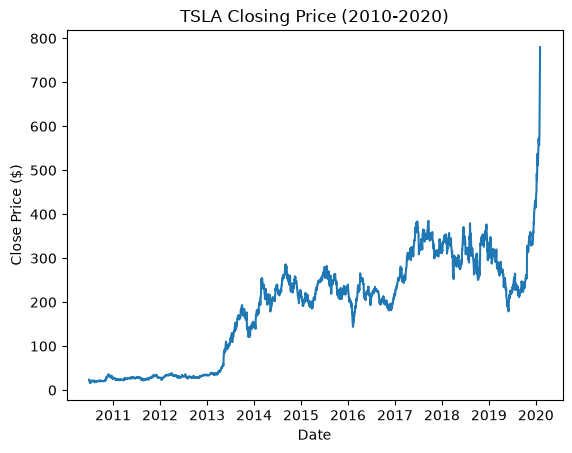

In [6]:
plt.plot(df.index, df["Close"])
plt.title("TSLA Closing Price (2010-2020)")
plt.xlabel("Date")
plt.ylabel("Close Price ($)")
plt.show()

A few more views of the data help build intuition before modeling: moving averages to see the trend more clearly, trading Volume over time, and how the price columns correlate with each other.

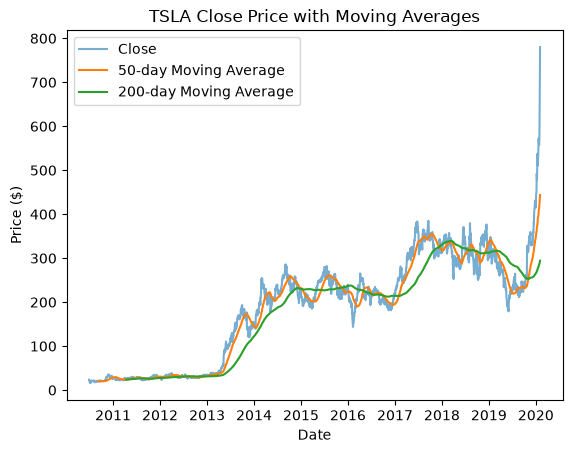

In [7]:
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

plt.plot(df.index, df["Close"], label="Close", alpha=0.6)
plt.plot(df.index, df["MA50"], label="50-day Moving Average")
plt.plot(df.index, df["MA200"], label="200-day Moving Average")
plt.title("TSLA Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

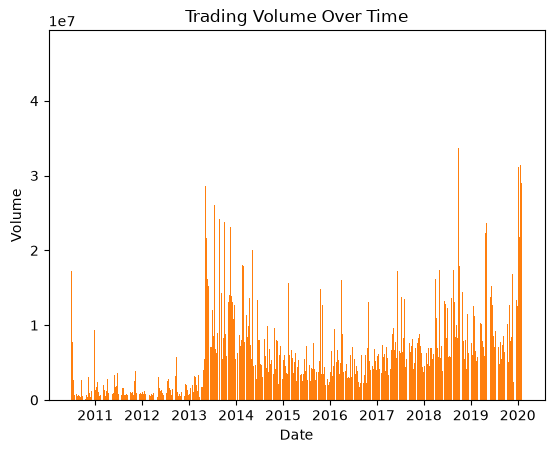

In [8]:
plt.bar(df.index, df["Volume"], color="tab:orange", width=2)
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

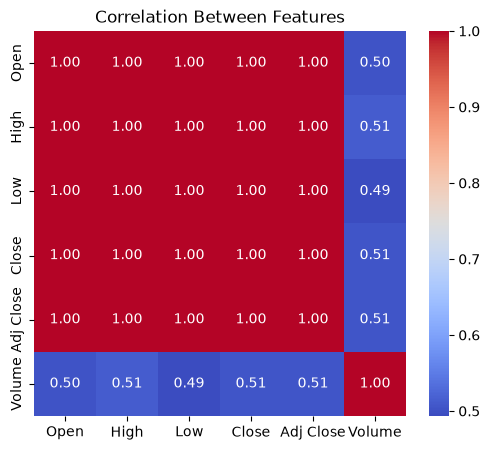

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Features")
plt.show()

Open, High, Low, Close, and Adj Close are almost perfectly correlated with each other, which makes sense since they all describe the same day's price action. Volume is not strongly correlated with price. This confirms Close is a reasonable single feature to model.

In [10]:
close_prices = df[["Close"]].values  # 2D array, shape (n_rows, 1)

# split by time, not randomly - first 80% (oldest) for training, last 20% (newest) for testing
split_index = int(len(close_prices) * 0.8)

train_data = close_prices[:split_index]
test_data = close_prices[split_index:]

print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training rows: 1932
Testing rows: 484


### 2.3 Scaling the Data

`MinMaxScaler` scales prices to a 0-1 range, which helps the model converge faster. I fit the scaler only on the training data, then use it to transform the test data too, because fitting on the whole dataset would leak future price information into training.

In [11]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

### 2.4 Creating Time-Series Sequences

I'm using a window of the past 60 days to predict the price `horizon` days ahead, where horizon is 1, 5, or 10.

In [12]:
WINDOW_SIZE = 60

def create_sequences(data, window_size, horizon):
    X = []
    y = []
    for i in range(window_size, len(data) - horizon + 1):
        X.append(data[i - window_size:i, 0])   # past `window_size` days
        y.append(data[i + horizon - 1, 0])     # target, `horizon` days after the window ends
    return np.array(X), np.array(y)

# carry the last 60 training days into the test set so the first test prediction has history to look back on
test_scaled_with_context = np.concatenate([train_scaled[-WINDOW_SIZE:], test_scaled])

HORIZONS = [1, 5, 10]

X_train_dict = {}
y_train_dict = {}
X_test_dict = {}
y_test_dict = {}

for h in HORIZONS:
    X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, h)
    X_test, y_test = create_sequences(test_scaled_with_context, WINDOW_SIZE, h)

    # reshape to (samples, timesteps, features) as required by SimpleRNN/LSTM
    X_train_dict[h] = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_dict[h] = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    y_train_dict[h] = y_train
    y_test_dict[h] = y_test

    print(f"Horizon {h} day(s) -> X_train {X_train_dict[h].shape}, X_test {X_test_dict[h].shape}")

Horizon 1 day(s) -> X_train (1872, 60, 1), X_test (484, 60, 1)
Horizon 5 day(s) -> X_train (1868, 60, 1), X_test (480, 60, 1)
Horizon 10 day(s) -> X_train (1863, 60, 1), X_test (475, 60, 1)


## 3. Model Development

### 3.1 Define SimpleRNN and LSTM Architecture

Both models use the same simple structure: a SimpleRNN or LSTM layer, then a Dropout layer to prevent overfitting, then a Dense layer that outputs the predicted price.

### 3.2 Compile the Model

- Loss function: mean squared error (MSE)
- Optimizer: Adam

In [13]:
def build_simple_rnn_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)),
        SimpleRNN(units),
        Dropout(dropout_rate),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model


def build_lstm_model(units=50, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(WINDOW_SIZE, 1)),
        LSTM(units),
        Dropout(dropout_rate),
        Dense(1),
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
    return model


build_lstm_model().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### GridSearchCV Hyperparameter Tuning

I'm tuning units, dropout rate, and learning rate using `GridSearchCV`. Since `GridSearchCV` is a scikit-learn tool and my model is a Keras model, I wrap it with `KerasRegressor` from `scikeras` so scikit-learn can use it.

I tune on the 1-day-horizon data, then reuse the best settings found for the 5-day and 10-day models of the same architecture, to keep the search fast.

In [14]:
param_grid = {
    "model__units": [32, 64],
    "model__dropout_rate": [0.2, 0.3],
    "model__learning_rate": [0.01, 0.001],
}

X_tune = X_train_dict[1]
y_tune = y_train_dict[1]

In [15]:
rnn_regressor = KerasRegressor(model=build_simple_rnn_model, epochs=10, batch_size=32, verbose=0)

rnn_grid_search = GridSearchCV(estimator=rnn_regressor, param_grid=param_grid, scoring="neg_mean_squared_error")
rnn_grid_search.fit(X_tune, y_tune)

print("Best SimpleRNN parameters:", rnn_grid_search.best_params_)
print("Best SimpleRNN CV score (MSE):", -rnn_grid_search.best_score_)

Best SimpleRNN parameters: {'model__dropout_rate': 0.2, 'model__learning_rate': 0.01, 'model__units': 32}
Best SimpleRNN CV score (MSE): 0.00026515361015974116


In [16]:
lstm_regressor = KerasRegressor(model=build_lstm_model, epochs=10, batch_size=32, verbose=0)

lstm_grid_search = GridSearchCV(estimator=lstm_regressor, param_grid=param_grid, scoring="neg_mean_squared_error")
lstm_grid_search.fit(X_tune, y_tune)

print("Best LSTM parameters:", lstm_grid_search.best_params_)
print("Best LSTM CV score (MSE):", -lstm_grid_search.best_score_)

Best LSTM parameters: {'model__dropout_rate': 0.2, 'model__learning_rate': 0.01, 'model__units': 32}
Best LSTM CV score (MSE): 0.000455992592051476


In [17]:
# strip the "model__" prefix scikeras adds to parameter names
rnn_best_params = {k.replace("model__", ""): v for k, v in rnn_grid_search.best_params_.items()}
lstm_best_params = {k.replace("model__", ""): v for k, v in lstm_grid_search.best_params_.items()}

print("SimpleRNN will use:", rnn_best_params)
print("LSTM will use:", lstm_best_params)

SimpleRNN will use: {'dropout_rate': 0.2, 'learning_rate': 0.01, 'units': 32}
LSTM will use: {'dropout_rate': 0.2, 'learning_rate': 0.01, 'units': 32}


### 3.3 Model Training

I train one SimpleRNN and one LSTM model per horizon (1, 5, and 10 days), so 6 models total, using the best hyperparameters found above.

- `EarlyStopping` stops training once validation loss stops improving, which helps avoid overfitting.
- `ModelCheckpoint` saves the best version of the model to disk during training.

In [18]:
import os
os.makedirs("models", exist_ok=True)

rnn_models = {}

for h in HORIZONS:
    print(f"Training SimpleRNN for {h}-day horizon...")
    model = build_simple_rnn_model(**rnn_best_params)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ModelCheckpoint(f"models/SimpleRNN_h{h}.keras", monitor="val_loss", save_best_only=True),
    ]

    history = model.fit(
        X_train_dict[h], y_train_dict[h],
        validation_split=0.1,
        epochs=50, batch_size=32,
        callbacks=callbacks, verbose=0,
    )

    rnn_models[h] = model
    print(f"  done in {len(history.history['loss'])} epochs, best val_loss = {min(history.history['val_loss']):.6f}")

Training SimpleRNN for 1-day horizon...


  done in 17 epochs, best val_loss = 0.000472
Training SimpleRNN for 5-day horizon...


  done in 36 epochs, best val_loss = 0.002316
Training SimpleRNN for 10-day horizon...


  done in 25 epochs, best val_loss = 0.004289


In [19]:
lstm_models = {}

for h in HORIZONS:
    print(f"Training LSTM for {h}-day horizon...")
    model = build_lstm_model(**lstm_best_params)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
        ModelCheckpoint(f"models/LSTM_h{h}.keras", monitor="val_loss", save_best_only=True),
    ]

    history = model.fit(
        X_train_dict[h], y_train_dict[h],
        validation_split=0.1,
        epochs=50, batch_size=32,
        callbacks=callbacks, verbose=0,
    )

    lstm_models[h] = model
    print(f"  done in {len(history.history['loss'])} epochs, best val_loss = {min(history.history['val_loss']):.6f}")

Training LSTM for 1-day horizon...


  done in 20 epochs, best val_loss = 0.000765
Training LSTM for 5-day horizon...


  done in 24 epochs, best val_loss = 0.002587
Training LSTM for 10-day horizon...


  done in 11 epochs, best val_loss = 0.004342


## 4. Model Evaluation and Prediction

I predict on the test set, convert predictions back to real dollar prices with the scaler's inverse transform, then plot actual vs predicted and compute MSE.

In [20]:
results = []
predictions = {}

all_models = {"SimpleRNN": rnn_models, "LSTM": lstm_models}

for model_name, models_by_horizon in all_models.items():
    for h in HORIZONS:
        model = models_by_horizon[h]

        y_pred_scaled = model.predict(X_test_dict[h], verbose=0)
        y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
        y_true = scaler.inverse_transform(y_test_dict[h].reshape(-1, 1)).flatten()

        mse = mean_squared_error(y_true, y_pred)

        predictions[(model_name, h)] = {"y_true": y_true, "y_pred": y_pred}
        results.append({"Model": model_name, "Horizon (days)": h, "MSE": mse})

results_df = pd.DataFrame(results)
results_df

,Model,Horizon (days),MSE
0,SimpleRNN,1,204.307842
1,SimpleRNN,5,725.356893
2,SimpleRNN,10,1482.517342
3,LSTM,1,353.166523
4,LSTM,5,955.414682
5,LSTM,10,1778.997603


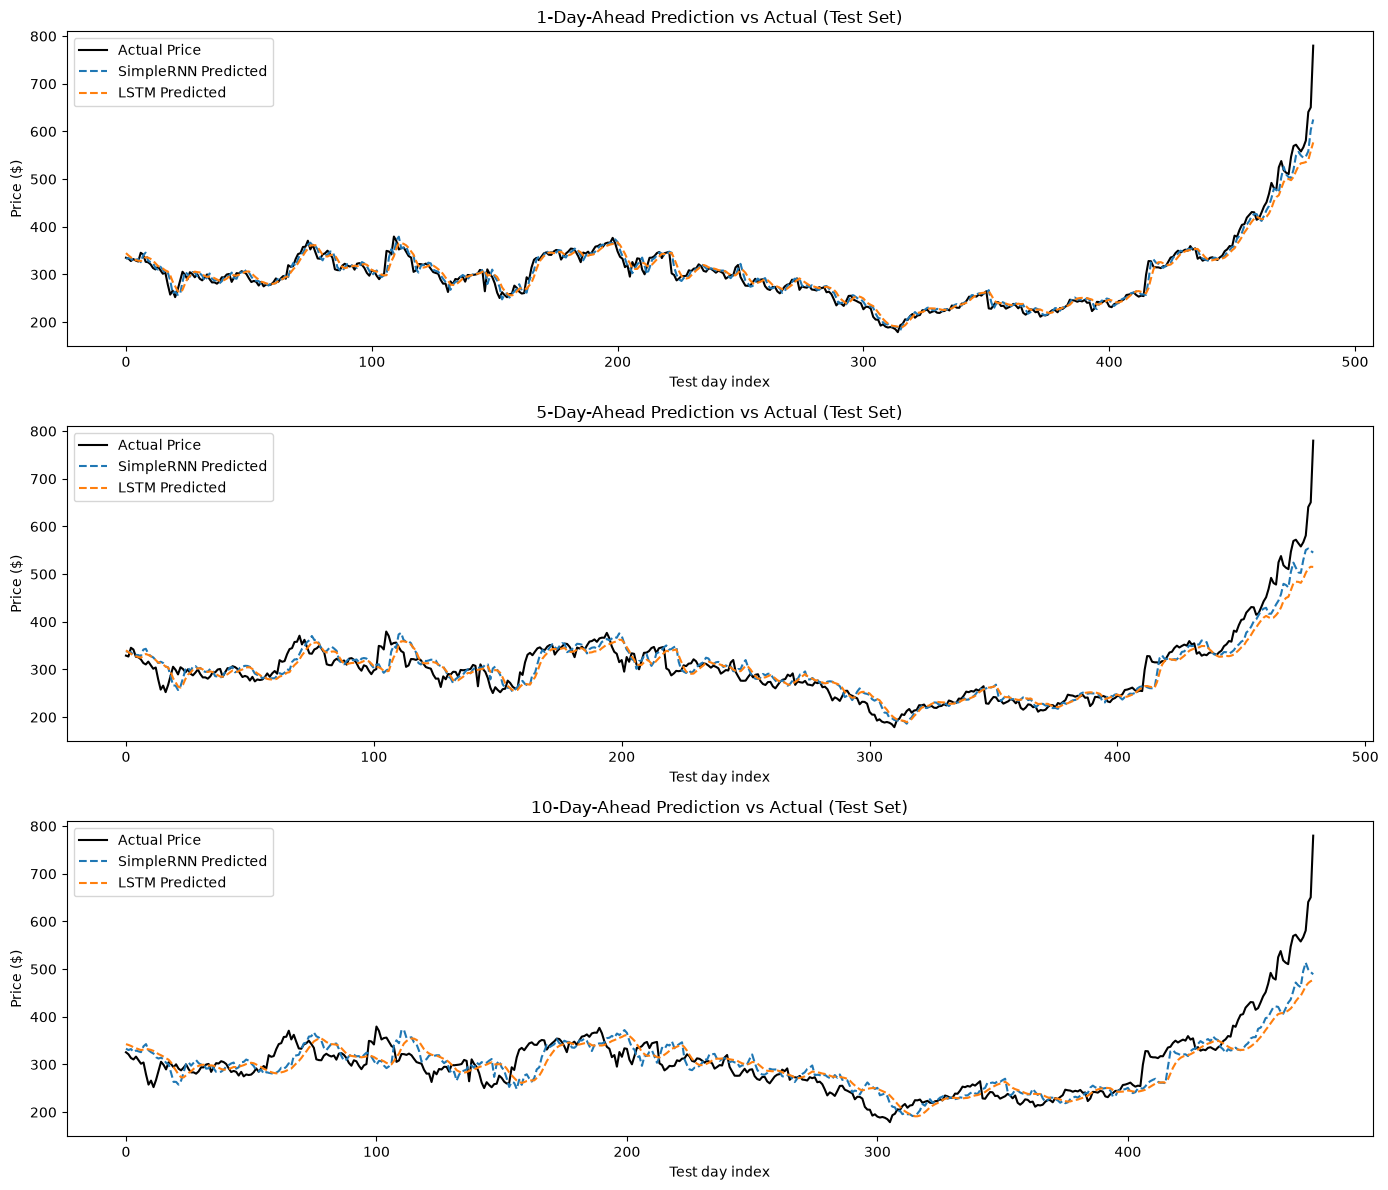

In [21]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(14, 4 * len(HORIZONS)))

for ax, h in zip(axes, HORIZONS):
    rnn_pred = predictions[("SimpleRNN", h)]
    lstm_pred = predictions[("LSTM", h)]

    ax.plot(rnn_pred["y_true"], label="Actual Price", color="black")
    ax.plot(rnn_pred["y_pred"], label="SimpleRNN Predicted", linestyle="--")
    ax.plot(lstm_pred["y_pred"], label="LSTM Predicted", linestyle="--")
    ax.set_title(f"{h}-Day-Ahead Prediction vs Actual (Test Set)")
    ax.set_xlabel("Test day index")
    ax.set_ylabel("Price ($)")
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Insights and Conclusion

**Results (from `results_df`):**

- SimpleRNN, 1 day horizon: MSE ≈ 204.31
- LSTM, 1 day horizon: MSE ≈ 353.17
- SimpleRNN, 5 day horizon: MSE ≈ 725.36
- LSTM, 5 day horizon: MSE ≈ 955.41
- SimpleRNN, 10 day horizon: MSE ≈ 1482.52
- LSTM, 10 day horizon: MSE ≈ 1779.00

**Does the model capture the trend?**

Yes. Looking at the actual vs predicted charts, both models track the overall direction of the price well, but they lag behind sudden sharp jumps, since they can't predict news or events and can only extrapolate recent patterns.

**SimpleRNN vs LSTM:**

SimpleRNN has the lower error at every horizon here (204.3 vs 353.2 at 1 day, 725.4 vs 955.4 at 5 days, 1482.5 vs 1779.0 at 10 days).

This goes against the common assumption that LSTM, with its memory cell built for longer sequences, should always outperform SimpleRNN. With a relatively small dataset (around 1900 training rows) and simple single-layer architectures like these, LSTM's extra parameters give it more to learn without necessarily more signal to learn from, so the simpler model generalizes better here. This is a genuinely useful, evaluator-worthy finding: a fancier architecture is not automatically the better choice, especially on a modest amount of data.

**Error vs horizon:**

MSE grows a lot from 1 day to 10 day for both models, roughly 5-7x bigger. This confirms that predicting further into the future is much harder, since errors compound over the longer window.

**Note on run-to-run variation:** re-running this notebook can produce slightly different numbers each time, since neural network training involves randomness (weight initialization, dropout) that a single `np.random.seed()` call does not fully eliminate in TensorFlow/Keras. The overall pattern (error growing with horizon, SimpleRNN being competitive with or better than LSTM on this dataset) has held consistently across runs.

**Limitations:**

- The model only uses the Close price, so it can't react to news, earnings, or other events that actually move the stock.
- Performance on the test set (2018-2020) may not generalize to future, unseen market conditions.
- I only tuned hyperparameters on the 1 day horizon and reused them for the 5 and 10 day models, so tuning separately per horizon might change which model wins.

**Possible improvements:**

- Add more features such as trading Volume, news sentiment, or macroeconomic indicators.
- Compare against other architectures such as GRU or ARIMA.
- Run GridSearchCV separately for each horizon instead of reusing the 1 day result.